# >Health Insurance Price Prediction using Linear Regression From Scratch❗:

In this project, we will make a linear regression model completely from scratch without using ml libraries  (e.g., sklearn, tensorflow) and use that model to predict health insurance price on the Health Insurance dataset.
This project would be a learing experience where we will dive into mathematical foundations of machine learning, and by making a linear regression model from scratch, gain a deep insight on the basic concepts and it's working



## Understanding Linear Regression
Before jumping into the code, let’s define linear regression thoroughly.

### What is Linear Regression?
Linear regression is a supervised learning algorithm used for predicting a continuous target variable (dependent variable) based on one or more input features (independent variables). It assumes that the relationship between the independent variables and the dependent variable is linear.

For **simple linear regression** (with one feature), the relationship is modeled by the equation:

**𝑦 = 𝛽0 + 𝛽1⋅ 𝑥**

Where:
**𝑦** is the dependent variable (target or output).
**𝑥** is the independent variable (input or feature).
**𝛽0** is the **intercept** (also called bias).
**𝛽1** is the **slope** (coefficient), which represents how much 𝑦 changes for a unit change in 𝑥.

In **multiple linear regression** (with multiple features), the equation becomes:

**𝑦= 𝛽0 + 𝛽1 𝑥1 + 𝛽2 𝑥2 +⋯+ 𝛽𝑛 𝑥𝑛**

Where:
**𝑦** is the target variable.
**𝑥1,𝑥2,…,𝑥𝑛** are the features (independent variables).
**𝛽0** is the intercept, and 
**𝛽1,𝛽2,…,𝛽𝑛** are the coefficients that need to be learned.


### Objective of Linear Regression
The goal of linear regression is to find the values of 
𝛽0 and 𝛽1 (in the simple case) or 𝛽0,𝛽1,…,𝛽𝑛 (in the multiple case) that **minimize the error** between the predicted values and the actual values.

This error is usually measured using a loss function, and the most common **loss function** in linear regression is the **Mean Squared Error (MSE)**.

## Implementing Linear Regression

We’ll take the following steps to implement linear regression from scratch:

1. **Data Collection**: We’ll use a real dataset to make our model more meaningful. For this, we will use the **Health Insurance dataset** to predict medical insurance costs of individual using details like age, sex, bmi, location, etc. 

2. **Data Preprocessing (Exploratory Data Analysis and Graphical Visualizations)**:
* Load and inspect the data.
* Explore and visualize the data.
* Technique to deal with skewed feature classes. 
* Handling outliers.
* Encode the categorical features.
* Normalize the data.
* Split the data into features (X) and target (y).

3. **Linear Regression Equation:**
* Define the linear regression equation and loss function (MSE).

4. **Gradient Descent:**
* Implement gradient descent to update the parameters 
𝛽0 and 𝛽1 (or 𝛽1,𝛽2,...) in the case of multiple features.

5. **Model Evaluation:**
* Evaluate the model using MSE.

6. **Visualization:**
* Plot the data points and the fitted regression line.
* Visualize the convergence of the cost function over iterations.

### Importing necessary libraries

In [1]:
# 1. Data Handling and Preprocessing
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations

# 2. Visualization Libraries
import matplotlib.pyplot as plt  # For plotting basic graphs
import seaborn as sns  # For statistical plots and better aesthetics (and also for the dataset)
import plotly.express as px  # For interactive plots
import plotly.graph_objects as go

# 3. Warning supression
import warnings
warnings.filterwarnings('ignore')

# DataSet loading and preparation:

In [2]:
# Load the dataset
df = pd.read_csv("/kaggle/input/ushealthinsurancedataset/insurance.csv")

# Display the first few rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Exploratory Data Analysis and Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Inference:
Dataset has 7 columns (3 categorical), all columns are filled with no null values.
Let's move on to:
## Visualizations

### Distribution of numerical features: (histograms)

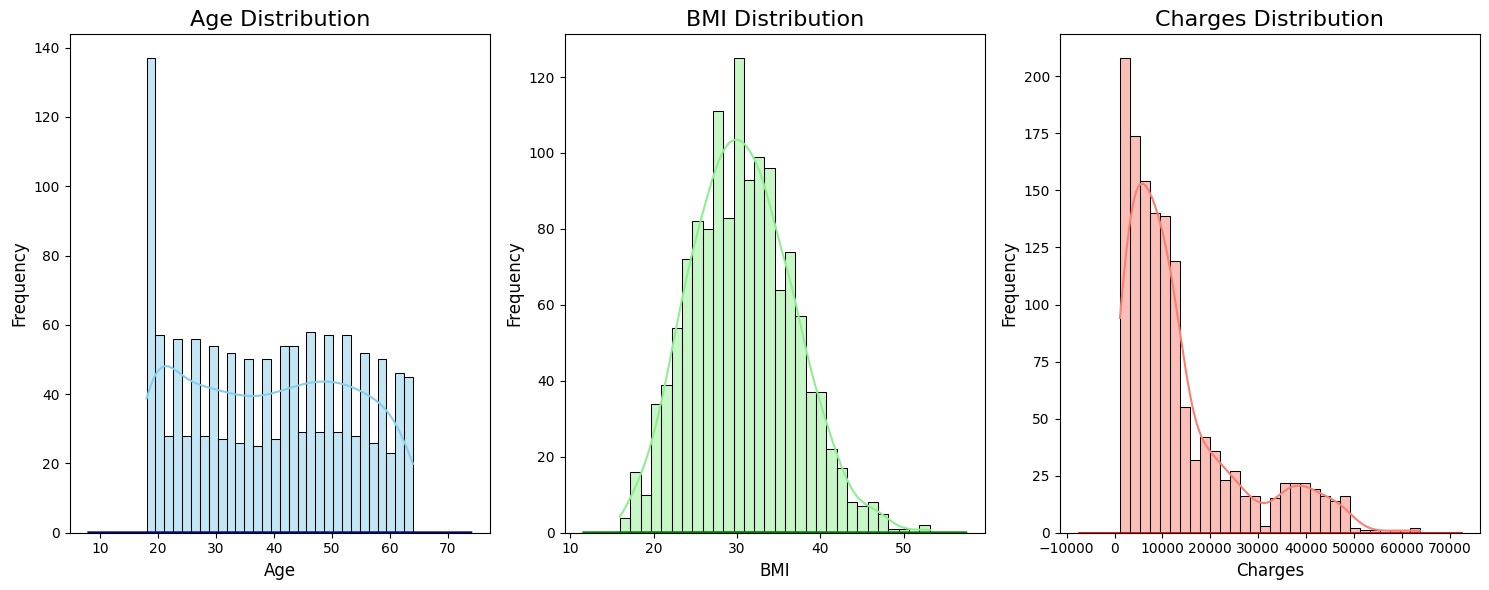

In [8]:
# Set up the figure for subplots
plt.figure(figsize=(15, 6))

# Plot histogram for age
plt.subplot(1, 3, 1)
sns.histplot(df['age'], kde=True, color='skyblue', bins=30)
sns.kdeplot(df['age'], color='darkblue', linewidth=2)
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot histogram for BMI
plt.subplot(1, 3, 2)
sns.histplot(df['bmi'], kde=True, color='lightgreen', bins=30)
sns.kdeplot(df['bmi'], color='green', linewidth=2)
plt.title('BMI Distribution', fontsize=16)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot histogram for charges
plt.subplot(1, 3, 3)
sns.histplot(df['charges'], kde=True, color='salmon', bins=30)
sns.kdeplot(df['charges'], color='red', linewidth=2)
plt.title('Charges Distribution', fontsize=16)
plt.xlabel('Charges', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()


* Age shows normal distribution
* BMI shows normal distribution
* Charges are skewed to right, We would try using log function to remove the skewdness

### Using log transform on charges to try getting rid of the skedwness

It is important to not have any skewed classes, as Linear Regression (and most of the other models) requires normal distribution, and its performance would take a drastic hit if we don't remove the skewdness!

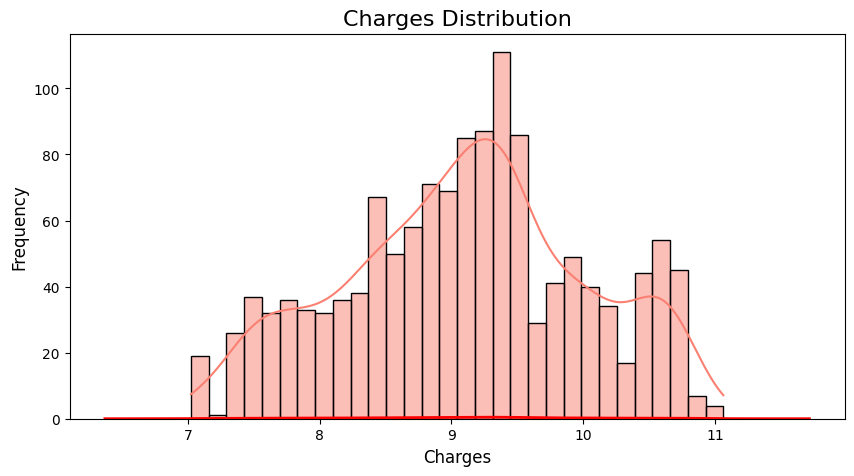

In [9]:
# Apply log transformation to 'charges' column
df['charges'] = np.log1p(df['charges'])  # np.log1p is log(1 + x)

# Plot histogram for charges
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='salmon', bins=30)
sns.kdeplot(df['charges'], color='red', linewidth=2)
plt.title('Charges Distribution', fontsize=16)
plt.xlabel('Charges', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

Charges show normal distribution now, we successfully removed the skewdness using log transform!

### Outlier detection using BoxPlots

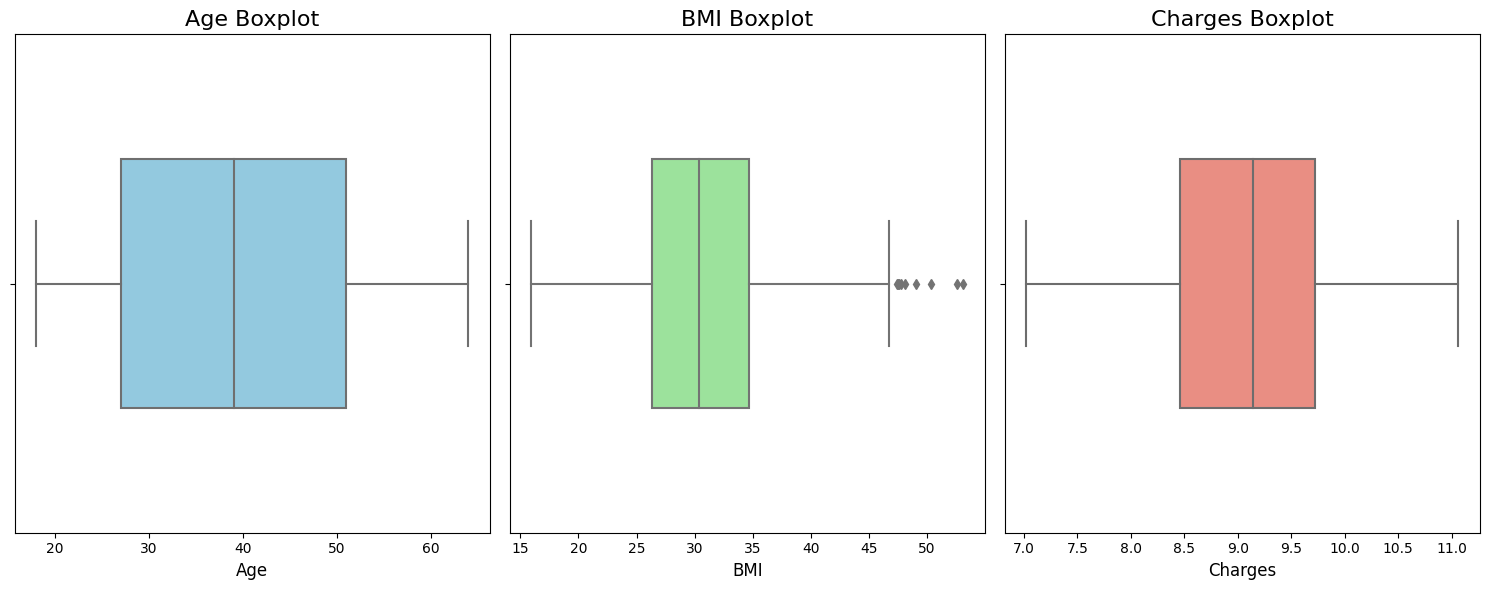

In [10]:
# Set up the figure for subplots
plt.figure(figsize=(15, 6))

# Boxplot for Age
plt.subplot(1, 3, 1)
sns.boxplot(x=df['age'], color='skyblue', width=0.5)
plt.title('Age Boxplot', fontsize=16)
plt.xlabel('Age', fontsize=12)

# Boxplot for BMI
plt.subplot(1, 3, 2)
sns.boxplot(x=df['bmi'], color='lightgreen', width=0.5)
plt.title('BMI Boxplot', fontsize=16)
plt.xlabel('BMI', fontsize=12)

# Boxplot for Charges
plt.subplot(1, 3, 3)
sns.boxplot(x=df['charges'], color='salmon', width=0.5)
plt.title('Charges Boxplot', fontsize=16)
plt.xlabel('Charges', fontsize=12)

plt.tight_layout()
plt.show()


### Dealing with Outliers
Some outliers are visible in BMI and Charges, and it is better to deal with them for good model performance

We will use the **IQR method** for outlier detection and removal, as it is more robust for most datasets and doesn’t assume a normal distribution.

### IQR (Interquartile Range) Method

* **What it is**: This method looks at the **Q1** (25th percentile) and **Q3** (75th percentile) values to define the IQR. Any values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are considered outliers.

* **Formula:**
    * Lower bound: *𝑄1−1.5×𝐼𝑄𝑅*
    * Upper bound: *𝑄3+1.5×𝐼𝑄𝑅*

In [11]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1_charges = df['charges'].quantile(0.25)
Q3_charges = df['charges'].quantile(0.75)
IQR_charges = Q3_charges - Q1_charges

Q1_bmi = df['bmi'].quantile(0.25)
Q3_bmi = df['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi

# Calculate lower and upper bounds for charges
lower_bound_charges = Q1_charges - 1.5 * IQR_charges
upper_bound_charges = Q3_charges + 1.5 * IQR_charges

# Calculate lower and upper bounds for bmi
lower_bound_bmi = Q1_bmi - 1.5 * IQR_bmi
upper_bound_bmi = Q3_bmi + 1.5 * IQR_bmi

# Identify outliers in charges and bmi
outliers_charges = df[(df['charges'] < lower_bound_charges) | (df['charges'] > upper_bound_charges)]
outliers_bmi = df[(df['bmi'] < lower_bound_bmi) | (df['bmi'] > upper_bound_bmi)]

# Display outliers
print(f"Outliers in Charges:\n{outliers_charges}\n")
print(f"Outliers in BMI:\n{outliers_bmi}\n")

Outliers in Charges:
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []

Outliers in BMI:
      age     sex    bmi  children smoker     region    charges
116    58    male  49.06         0     no  southeast   9.339817
286    46  female  48.07         2     no  northeast   9.152068
401    47    male  47.52         1     no  southeast   8.997756
543    54  female  47.41         0    yes  southeast  11.063061
847    23    male  50.38         1     no  southeast   7.799366
860    37  female  47.60         2    yes  southwest  10.738883
1047   22    male  52.58         1    yes  southeast  10.703298
1088   52    male  47.74         1     no  southeast   9.185013
1317   18    male  53.13         0     no  southeast   7.060015



9 outliers in BMI and 139 in charges in total detected. We can either remove the outliers or *cap* them, we will remove the outlier values as capping would imbalance the distribution of the dataset

In [12]:
# Display the size of the current dataframe with outliers
print(df.shape)

# Remove the outliers in-place by filtering the dataframe
df = df[(df['charges'] >= lower_bound_charges) & (df['charges'] <= upper_bound_charges)]

df = df[(df['bmi'] >= lower_bound_bmi) & (df['bmi'] <= upper_bound_bmi)]

# Display the size of cleaned dataframe
df.shape

(1338, 7)


(1329, 7)

In [13]:
# Reset the index after removing the outliers
df = df.reset_index(drop=True)

## Reviewing the Distribution after outlier removal

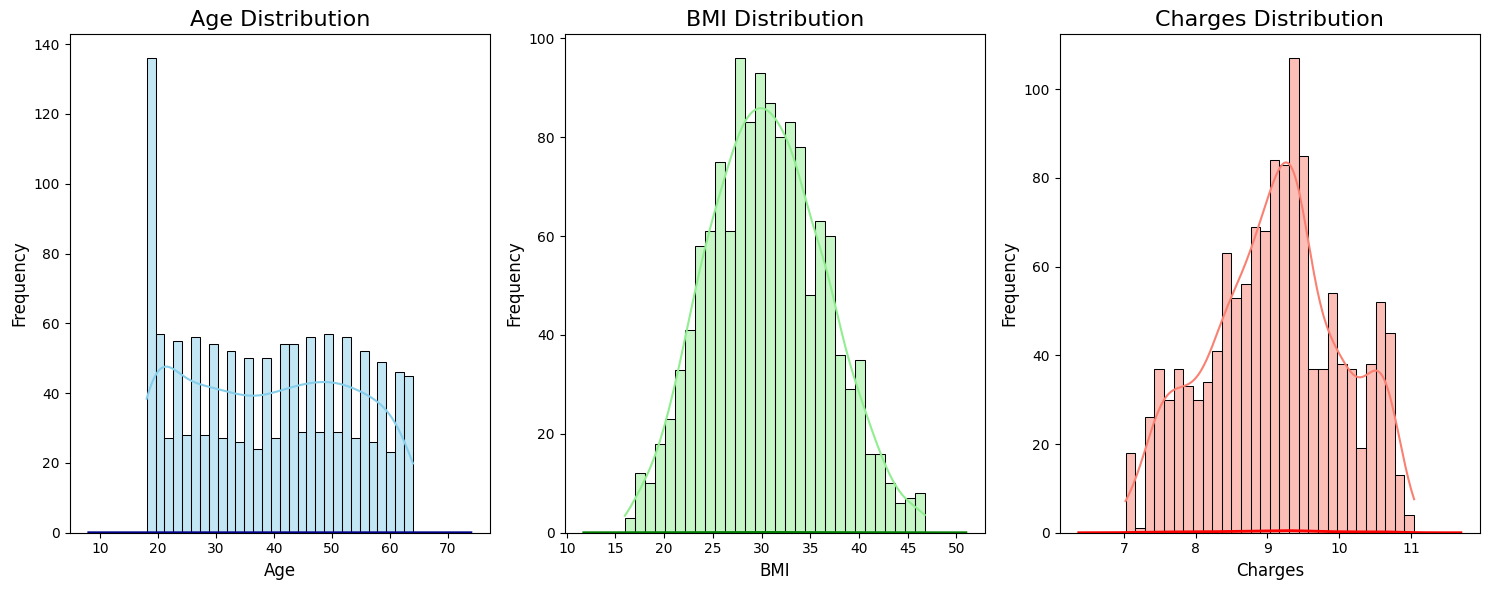

In [14]:
# Set up the figure for subplots
plt.figure(figsize=(15, 6))

# Plot histogram for age
plt.subplot(1, 3, 1)
sns.histplot(df['age'], kde=True, color='skyblue', bins=30)
sns.kdeplot(df['age'], color='darkblue', linewidth=2)
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot histogram for BMI
plt.subplot(1, 3, 2)
sns.histplot(df['bmi'], kde=True, color='lightgreen', bins=30)
sns.kdeplot(df['bmi'], color='green', linewidth=2)
plt.title('BMI Distribution', fontsize=16)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot histogram for charges
plt.subplot(1, 3, 3)
sns.histplot(df['charges'], kde=True, color='salmon', bins=30)
sns.kdeplot(df['charges'], color='red', linewidth=2)
plt.title('Charges Distribution', fontsize=16)
plt.xlabel('Charges', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()


### Distribution of Categorical Features (Pie Charts and BarPlots)

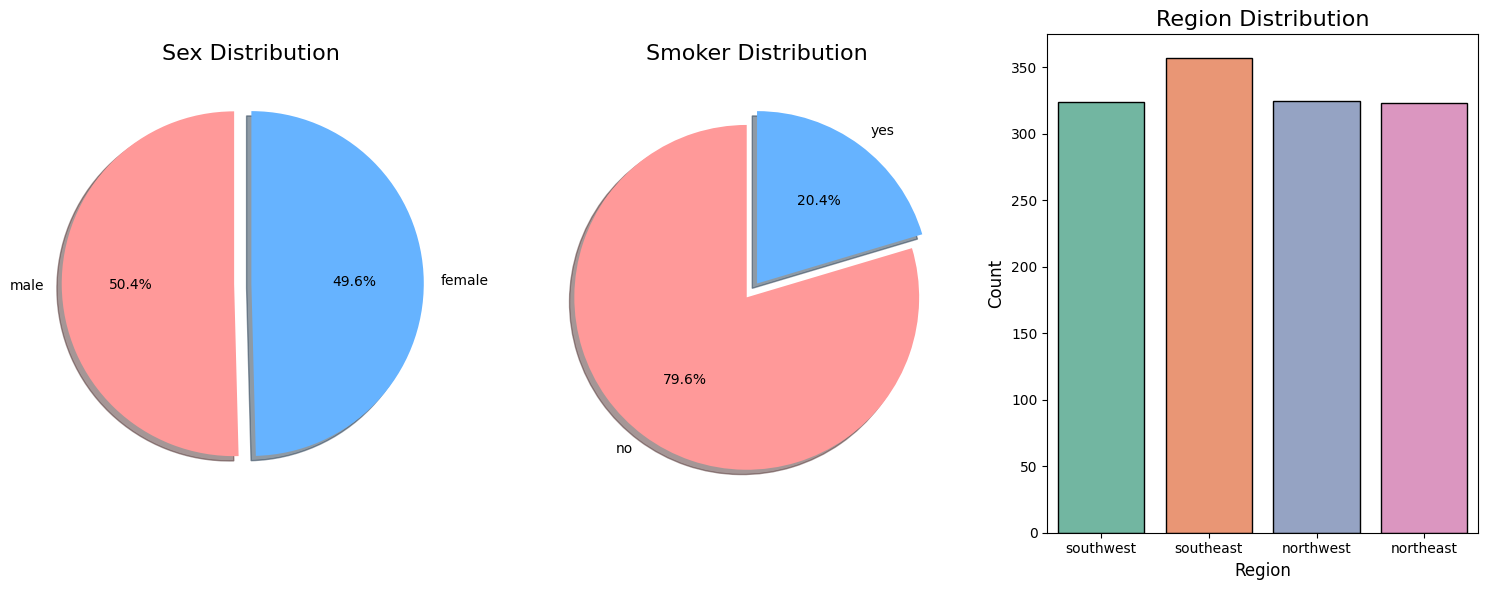

In [15]:
# Set up the figure for subplots
plt.figure(figsize=(15, 6))

# Pie chart for Sex
plt.subplot(1, 3, 1)
sex_counts = df['sex'].value_counts()
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, 
        colors=['#ff9999','#66b3ff'], shadow=True, explode=(0.1, 0))  # Adding explosion and shadow
plt.title('Sex Distribution', fontsize=16)

# Pie chart for Smoker
plt.subplot(1, 3, 2)
smoker_counts = df['smoker'].value_counts()
plt.pie(smoker_counts, labels=smoker_counts.index, autopct='%1.1f%%', startangle=90, 
        colors=['#ff9999','#66b3ff'], shadow=True, explode=(0.1, 0))  # Adding explosion and shadow
plt.title('Smoker Distribution', fontsize=16)

# Bar plot for Region (because it's a multi-category variable)
plt.subplot(1, 3, 3)
sns.countplot(x=df['region'], palette='Set2', edgecolor='black')
plt.title('Region Distribution', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

### Feature relationships with charges (ScatterPlot)

In [16]:
# Scatter plot for Age vs Charges
fig_age = px.scatter(df, x='age', y='charges', title='Age vs Charges', 
                     labels={'age': 'Age', 'charges': 'Charges'}, 
                     color='age', color_continuous_scale='Viridis')
fig_age.update_layout(title_font_size=20)
fig_age.show()

# Scatter plot for BMI vs Charges
fig_bmi = px.scatter(df, x='bmi', y='charges', title='BMI vs Charges', 
                     labels={'bmi': 'BMI', 'charges': 'Charges'}, 
                     color='bmi', color_continuous_scale='Viridis')
fig_bmi.update_layout(title_font_size=20)
fig_bmi.show()

### Correlation HeatMap (interactive)

In [17]:
# Correlation matrix for numerical features
correlation_matrix = df[['age', 'bmi', 'children', 'charges']].corr()
print(correlation_matrix)

# Plot interactive heatmap using Plotly
fig = px.imshow(correlation_matrix, text_auto=True, color_continuous_scale='algae', title="Correlation Heatmap")
fig.update_layout(title_font_size=20, xaxis_title="Features", yaxis_title="Features")
fig.show()

               age       bmi  children   charges
age       1.000000  0.114686  0.043041  0.529296
bmi       0.114686  1.000000  0.017355  0.133920
children  0.043041  0.017355  1.000000  0.161725
charges   0.529296  0.133920  0.161725  1.000000


# Feature Scaling and Engineering

## Encoding Categorical Variables: 
We need to handle categorical variables (sex, smoker, region) by encoding them into numeric values so they can be fed into the model.
* For binary features like sex and smoker, we can use *Label Encoding* (0 or 1).
* For multi-category features like region, *One-Hot Encoding* would be more appropriate.

As we are making this model from "scratch", we will also not be using any libraries for encodings.

In [18]:
# 1. Encoding binary categorical variables (sex and smoker)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# 2. One-Hot Encoding for region
# Create a new column for each unique region and assign 0 or 1 based on the value
regions = df['region'].unique()  # Get unique regions
for region in regions:
    df[region] = df['region'].apply(lambda x: 1 if x == region else 0)

# Drop the original 'region' column as it is now encoded
df.drop('region', axis=1, inplace=True)

# Display the transformed dataframe to ensure encoding was done correctly
df.head()

,age,sex,bmi,children,smoker,charges,southwest,southeast,northwest,northeast
0,19,1,27.900,0,1,9.734236,1,0,0,0
1,18,0,33.770,1,0,7.453882,0,1,0,0
2,28,0,33.000,3,0,8.400763,0,1,0,0
3,33,0,22.705,0,0,9.998137,0,0,1,0
4,32,0,28.880,0,0,8.260455,0,0,1,0


## Feature Scaling
Since we're dealing with different scales (e.g., age is much smaller than charges), we'll need to normalize or standardize the features so they are on the same scale for the linear regression.
 We typically use **Z-Score Normalization** or **Min-Max Scaling**, but in this case, we will use **Standardization**

### Standardization:
Standardization scales the features so they have a mean of 0 and a standard deviation of 1. This is important because it ensures that each feature contributes equally to the model (i.e., features with larger scales don’t dominate the learning process).

The formula for standardization is: **𝑍=(𝑋−𝜇)/𝜎**

Where: 
* 𝑋 is the original value of the feature.
* 𝜇 is the mean of the feature.
* 𝜎 is the standard deviation of the feature.
* 𝑍 is the scaled value.

In [19]:
# Function to standardize a column
def standardize_column(col):
    mean = col.mean()
    std = col.std()
    return (col - mean) / std

# Apply standardization to all numeric columns
columns_to_standardize = ['age', 'bmi', 'children', 'charges']  # We standardize numeric columns only

for col in columns_to_standardize:
    df[col] = standardize_column(df[col])

# Display the dataframe to verify the scaling
df.head()

,age,sex,bmi,children,smoker,charges,southwest,southeast,northwest,northeast
0,-1.438223,1,-0.445502,-0.907598,1,0.695195,1,0,0,0
1,-1.509408,0,0.546061,-0.079734,0,-1.793388,0,1,0,0
2,-0.797554,0,0.415992,1.575994,0,-0.760043,0,1,0,0
3,-0.441628,0,-1.323044,-0.907598,0,0.983194,0,0,1,0
4,-0.512813,0,-0.279960,-0.907598,0,-0.913163,0,0,1,0


In [20]:
# Verify the scaling
df[columns_to_standardize].mean(), df[columns_to_standardize].std()

## Desired output: mean close to 0, std close to 1

(age        -2.459365e-16
 bmi        -2.085114e-16
 children    6.282075e-17
 charges     1.443541e-16
 dtype: float64,
 age         1.0
 bmi         1.0
 children    1.0
 charges     1.0
 dtype: float64)

Standard Deviation is 1 and mean is vary close to 0 (numbers like -1.672802e-16 are very-very small, and are incredibly close to 0, don't let them confuse you)

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1329.0,-2.459365e-16,1.000000,-1.509408,-0.868740,-0.014516,0.839709,1.765118
sex,1329.0,4.958616e-01,0.500171,0.000000,0.000000,0.000000,1.000000,1.000000
bmi,1329.0,-2.085114e-16,1.000000,-2.462412,-0.729288,-0.040093,0.666839,2.738648
children,1329.0,6.282075e-17,1.000000,-0.907598,-0.907598,-0.079734,0.748130,3.231721
smoker,1329.0,2.039127e-01,0.403057,0.000000,0.000000,0.000000,0.000000,1.000000
charges,1329.0,1.443541e-16,1.000000,-2.262910,-0.691427,0.051552,0.675736,2.125021
southwest,1329.0,2.437923e-01,0.429531,0.000000,0.000000,0.000000,0.000000,1.000000
southeast,1329.0,2.686230e-01,0.443410,0.000000,0.000000,0.000000,1.000000,1.000000
northwest,1329.0,2.445448e-01,0.429979,0.000000,0.000000,0.000000,0.000000,1.000000
northeast,1329.0,2.430399e-01,0.429080,0.000000,0.000000,0.000000,0.000000,1.000000


## Splitting the DataSet (train test split)

We will be doing this *manually* as well instead using sklearn library for the task

**Steps:**
* **Shuffling** the dataset
* **Splitting** the dataset (80-20 split)

In [22]:
# Set the random seed for reproducibility
np.random.seed(42)

# Shuffle the dataset indices
shuffled_indices = np.random.permutation(df.index)

# Define the split ratio (80% train, 20% test)
train_size = int(0.8 * len(df))

# Split the data into training and testing sets
train_indices = shuffled_indices[:train_size]
test_indices = shuffled_indices[train_size:]

# Create training and testing datasets
df_train = df.iloc[train_indices]
df_test = df.iloc[test_indices]

# Display the shape of the training and testing sets
print(f'Training set shape: {df_train.shape}')
print(f'Test set shape: {df_test.shape}')

df_train.columns

Training set shape: (1063, 10)
Test set shape: (266, 10)


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'southwest',
       'southeast', 'northwest', 'northeast'],
      dtype='object')

Congratulations on reaching here!! Here, a question for you: (think it hard, this is a challenge to your geek knowledge)

Why do all programmers generally only use **42** and no other number? 
What is the big secret behind this number? 

## Preparing the features (X) and label (y) from the train and test dataframes

In [23]:
# Prepare the features (X) and target (y) for the training set

# Select the columns for features (excluding 'charges')
X_train = df_train[['age', 'bmi', 'children', 'sex', 'smoker', 'southwest', 'southeast', 'northwest', 'northeast']].values

# Select the target variable 'charges'
y_train = df_train['charges'].values

# Add a column of ones to X for the bias term (intercept, theta_0). Why? (explained below)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]  # Add intercept column

# Display the shapes of the prepared features and labels
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (1063, 10)
y_train shape: (1063,)


In [24]:
# Prepare the features (X) and target (y) for the test set

# Select the columns for features (excluding 'charges')
X_test = df_test[['age', 'bmi', 'children', 'sex', 'smoker', 'southwest', 'southeast', 'northwest', 'northeast']].values

# Select the target variable 'charges'
y_test = df_test['charges'].values

# Add a column of ones to X for the bias term (intercept, theta_0)
X_test = np.c_[np.ones(X_test.shape[0]), X_test]  # Add intercept column

# Display the shapes of the prepared features and labels
print(f'X_train shape: {X_test.shape}')
print(f'y_train shape: {y_test.shape}')

X_train shape: (266, 10)
y_train shape: (266,)


**Why did we add a column for intercept (bias)?**

The bias term needs to be explicitly accounted for during the calculation of the predictions and in the gradient update rule. Adding a column of ones to the features allows us to treat the intercept as part of the model weights and properly apply gradient descent to all parameters (including the intercept).

# Designing the Linear Regression

## Step 1. Initialize Parameters:
* We need to initialize the weights (𝜃) for our features and the bias term.
* The weights are usually initialized to small random values, and the intercept term can start as zero (or any small value).

In [25]:
# Initialize parameters (weights) to zeros
def initialize_parameters(n_features):
    theta = np.zeros(n_features)  # Including the intercept term
    return theta

## Step 2. Define the Hypothesis Function:

* Our model will use the **hypothesis function**: 
                **𝑦^=𝑋⋅𝜃**
* Where 𝑋 is the input features (with the intercept column of ones), and 𝜃 is the weight vector (including the intercept term).


In [26]:
# Hypothesis function
def hypothesis(X, theta):
    return np.dot(X, theta)  # X * theta

## Step 3. Compute the Loss (Cost Function):

We'll use Mean Squared Error (MSE) as the cost function, which is a common loss function in regression tasks:
## 𝑀𝑆𝐸=
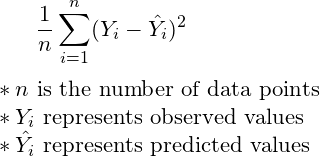


In [27]:
# Cost function (Mean Squared Error)
def compute_cost(X, y, theta):
    n = len(y)
    predictions = hypothesis(X, theta)
    cost = (1/(2*n)) * np.sum(np.square(predictions - y))  # MSE cost function
    return cost

## Step 4. Compute the Gradient:

The gradient of the loss with respect to the parameters (𝜃) is computed using:
## ∇𝜃𝑀𝑆𝐸=(2𝑋^𝑇(𝑋𝜃−𝑦))/n
This gradient tells us how to update the parameters to reduce the error.

In [28]:
# Compute the gradient of the cost function
def compute_gradient(X, y, theta):
    n = len(y)
    predictions = hypothesis(X, theta)
    gradient = (1/n) * np.dot(X.T, (predictions - y))  # Gradient
    return gradient

## Step 5. Update Parameters: (Gradient Descent)

Using **Gradient Descent**, we update the parameters by moving in the direction of the negative gradient:
## 𝜃=𝜃−𝛼⋅∇𝜃𝑀𝑆𝐸

Where: 
𝛼 is the **learning rate** (a small value determining the step size for each update).

In [29]:
# Gradient Descent
def gradient_descent(X, y, theta, learning_rate, iterations):
    cost_history = []
    
    for _ in range(iterations):
        gradient = compute_gradient(X, y, theta)
        theta = theta - learning_rate * gradient  # Update weights
        
        # Record the cost for each iteration
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        
    return theta, cost_history

## Putting it all together
Now let's initialize our parameters, set our learning rate, and perform the gradient descent to train the model.

In [30]:
# Initialize parameters
n_features = X_train.shape[1]  # Number of features (including the intercept term)
theta = initialize_parameters(n_features)

# Set learning rate and number of iterations
learning_rate = 0.05
iterations = 1000

# Perform Gradient Descent
theta_optimal, cost_history = gradient_descent(X_train, y_train, theta, learning_rate, iterations)

# Display the final optimized parameters (weights and intercept)
print("Optimized parameters (theta):", theta_optimal)


Optimized parameters (theta): [-0.29711154  0.52055137  0.09134574  0.14114477  0.07372395  1.66642286
 -0.12515651 -0.14678902 -0.06863107  0.04346505]


# Making Predictions

In [31]:
# Predictions on the test set
def predict(X, theta):
    return np.dot(X, theta.T)  # Matrix multiplication for predictions

y_pred = predict(X_test, theta_optimal)  # Predicted values on the test set

y_pred.shape

(266,)

# Model Evaluation (Mean Squared Error and R²)

## Mean Squared Error

In [32]:
# Mean Squared Error (MSE) function (Same as the cost function used earlier)
def mean_squared_error(y_true, y_pred):
    n = len(y_true)
    return (1/n) * np.sum((y_pred - y_true) ** 2)

# Calculate MSE on the test set
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) on Test Set: {mse}")

Mean Squared Error (MSE) on Test Set: 0.22322839013467297


## R²
R² (Coefficient of Determination) is a measure of how well the model's predictions match the actual data. It’s calculated as:

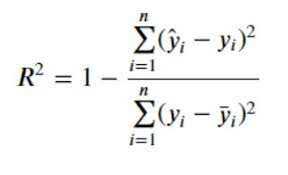

In [33]:
# R-squared (R²) function
def r_squared(y_true, y_pred):
    # Calculate the mean of the true values
    y_mean = np.mean(y_true)
    
    # Calculate the total sum of squares (SST)
    total_sum_of_squares = np.sum((y_true - y_mean) ** 2)
    
    # Calculate the residual sum of squares (SSE)
    residual_sum_of_squares = np.sum((y_true - y_pred) ** 2)
    
    # Calculate R²
    r2 = 1 - (residual_sum_of_squares / total_sum_of_squares)
    return r2

# Calculate R² on the test set
r2 = r_squared(y_test, y_pred)
print(f"R-squared (R²) on Test Set: {r2}")


R-squared (R²) on Test Set: 0.7852294274579548


## Interactive visualization for R² performance metrics

In [34]:
# Creating a gauge chart for R-squared
fig_r2 = go.Figure(go.Indicator(
    mode="gauge+number",
    value=r2,
    title={'text': "R-squared (R²)"},
    gauge={'axis': {'range': [None, 1]}, 'bar': {'color': 'blue'}, 'steps': [
        {'range': [0, 0.25], 'color': "red"},
        {'range': [0.25, 0.5], 'color': "orange"},
        {'range': [0.5, 0.75], 'color': "yellow"},
        {'range': [0.75, 1], 'color': "green"}]}))

fig_r2.update_layout(title_font_size=20)
fig_r2.show()


## Inference from the test results:

The linear regression model built to predict healthcare charges has performed quite well on the test set:

* **Mean Squared Error (MSE):** 0.223
    * The **MSE** indicates that, on average, the model’s predictions deviate from the actual values by a factor of **0.237**. This is a relatively low error, which suggests that the model is accurately capturing the trend of healthcare costs in the dataset.

* **R-squared (R²):** 0.785
    * An **R²** of **0.785** means that the model is able to explain **78.5%** of the variability in the healthcare charges. This is a strong result, as it shows that a large portion of the variance in charges is explained by the features in the model (e.g., age, BMI, smoker status, etc.).

## Key Takeaways:

1. **Model Performance:**
    * The model successfully captures a significant portion of the variation in healthcare charges, with 76.38% of the variance explained. This is considered a good result for linear regression, especially for real-world datasets where the relationships between features can be complex and nonlinear. And, let's not forget the entire project was **made from scratch** with **no libraries** used (except for data handling and visualization)
2. **Error in Predictions:**
    * With an **MSE of 0.223**, we can conclude that the model is making predictions with a reasonable degree of accuracy. While there’s still room for improvement, the error is not excessively high, indicating that the model is performing decently.
3. **Applicability:**
    * The model can be effectively used for basic predictions of healthcare costs, with the understanding that there may be other non-linear factors influencing the target variable that linear regression does not capture. Further improvements could involve more advanced models or feature engineering.

## Predictions vs Actual plot

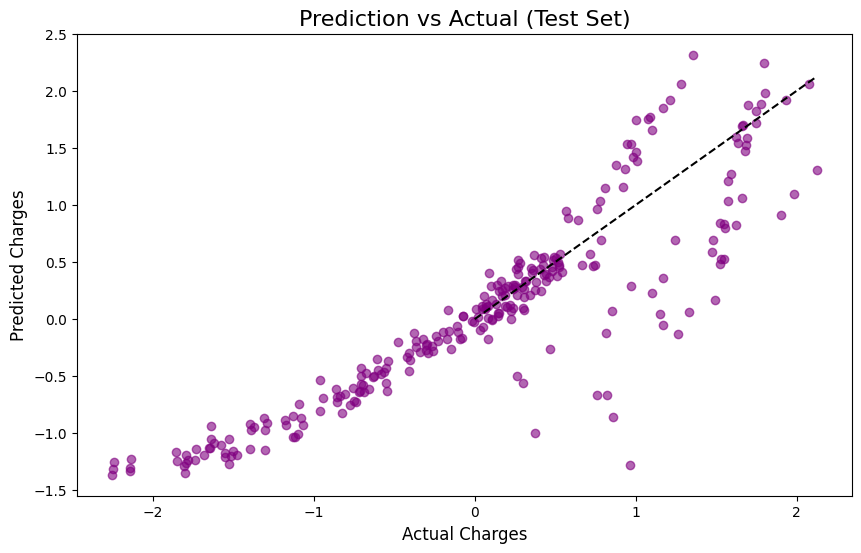

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='purple', alpha=0.6)
plt.plot([0, max(y_test)], [0, max(y_test)], color='black', linestyle='--')
plt.title('Prediction vs Actual (Test Set)', fontsize=16)
plt.xlabel('Actual Charges', fontsize=12)
plt.ylabel('Predicted Charges', fontsize=12)
plt.show()

# Error Analysis: (Resudial Plot)

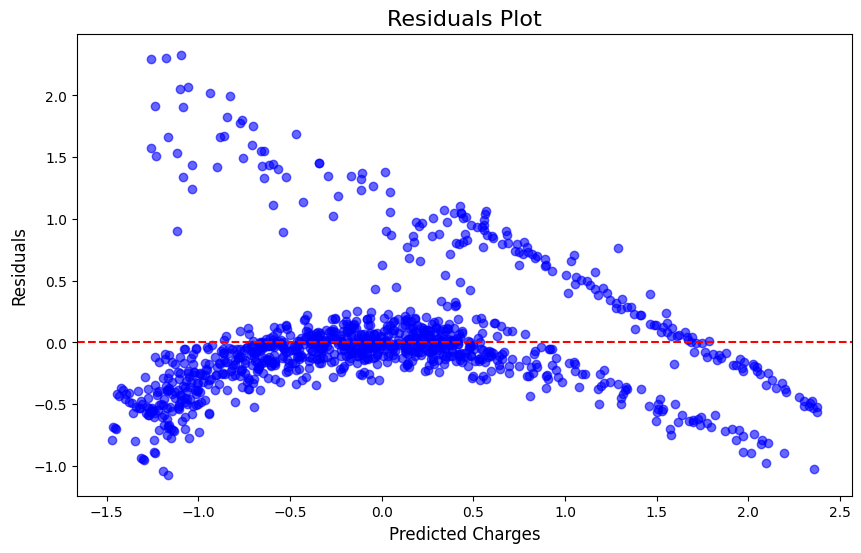

In [36]:
import matplotlib.pyplot as plt

# Residuals plot
y_pred_train = np.dot(X_train, theta_optimal.T)
residuals = y_train - y_pred_train

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_train, residuals, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Plot', fontsize=16)
plt.xlabel('Predicted Charges', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.show()

### Distribution of Residuals

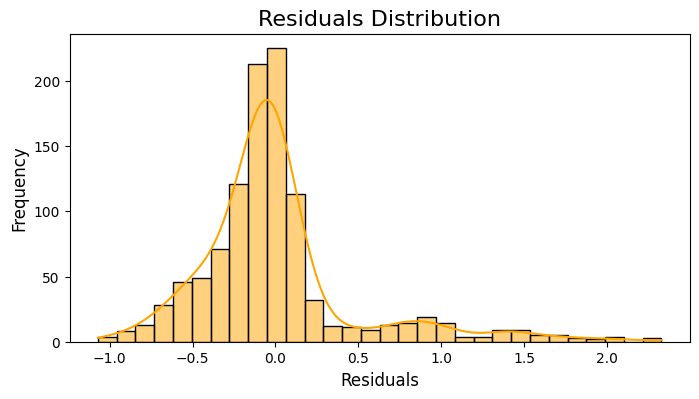

In [37]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='orange', bins=30)
plt.title('Residuals Distribution', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## Inference from Residual Plots

To evaluate the performance of our **linear regression model**, we analyze the residuals, which represent the difference between actual and predicted values. A well-fitted linear model should exhibit **randomly distributed residuals** without any systematic patterns.

1. **Residuals Plot Interpretation**: The residuals are **evenly scattered** around the zero line, indicating that the model does not have major systematic biases.
The spread of residuals appears **homoscedastic** (constant variance), suggesting that the model maintains a consistent level of prediction accuracy across different values.
There are no strong visible trends or patterns in the residuals, meaning that the assumption of **linearity** is largely satisfied.

3. **Residual Distribution Analysis**: The residuals follow a **roughly normal distribution**, as seen in the histogram.
This suggests that the model's errors are **randomly distributed**, a key assumption for linear regression validity.
The presence of slight tails in the distribution may indicate that some extreme values exist, but overall, the distribution appears well-behaved.

4. **Performance Evaluation**: The model explains a significant portion of the variance in the data, showing **good predictive power**.
Since the residuals are centered around zero with a normal spread, it indicates that the model does not overfit or underfit significantly.

### Conclusion
The residual analysis confirms that our **linear regression model** effectively captures the relationship between the features and the target variable. The key takeaways are:
* The model satisfies **linearity** and **homoscedasticity** assumptions.
*  The residuals are **normally distributed**, meaning errors occur randomly and not due to systematic flaws.
*  The predictions are **statistically reliable** for the given dataset.

# The End!👋
# This project was a success, and I am extremely pleased that the model we created managed to exceed my expectations. 

## Thanks for taking out your precious time to visit this notebook, if you have any suggestions and/or wish to contact me, here is a list to all my socials, feel free to send a hi:
## https://linktr.ee/bhaveshpant